In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv('08-email_classification_svm.csv')

In [3]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [5]:
df['email_type'].unique()

array([0, 1])

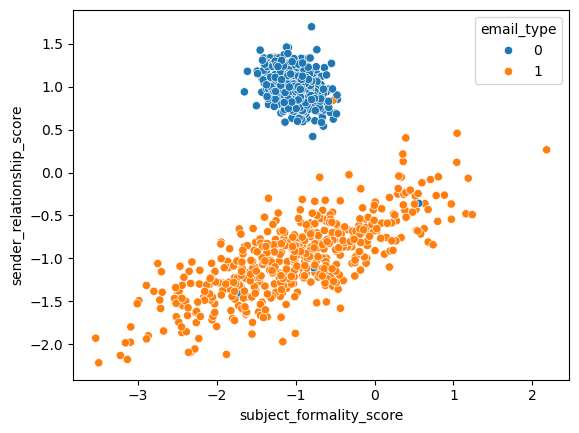

In [6]:
sns.scatterplot(x=df['subject_formality_score'], y=df['sender_relationship_score'], hue=df['email_type'])
plt.show()

In [7]:
X = df[['subject_formality_score','sender_relationship_score']].values
y = df['email_type'].values

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

In [11]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

In [12]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [13]:
X_train.ndim

2

In [14]:
y_train.ndim

2

In [15]:
import torch.nn as nn

In [16]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2 , out_features=5)
        self.layer_2 = nn.Linear(in_features=5 , out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x))
        

In [17]:
model_0 = ClassificationModel()

In [18]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [19]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test,y_pred).sum().item()
    accuracy = correct / len(y_test) * 100    
    return accuracy

In [20]:
model_0(X_test)[:5]

tensor([[-0.1681],
        [ 0.3907],
        [-0.1141],
        [ 0.3322],
        [-0.1632]], grad_fn=<SliceBackward0>)

In [21]:
y_logits = model_0(X_test)[:5]

In [22]:
torch.sigmoid(y_logits)

tensor([[0.4581],
        [0.5964],
        [0.4715],
        [0.5823],
        [0.4593]], grad_fn=<SigmoidBackward0>)

In [23]:
y_pred_probs = torch.sigmoid(y_logits)

In [24]:
torch.round(y_pred_probs)

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]], grad_fn=<RoundBackward0>)

In [25]:
y_preds = torch.round(y_pred_probs)

In [26]:
y_preds

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]], grad_fn=<RoundBackward0>)

In [27]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [28]:
calculate_accuracy(y_test[:5],y_preds)

100.0

In [29]:
torch.manual_seed(42)
epoch = 100

for epoch in range(epoch):
    
    model_0.train()
    
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_test=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits,y_test)
        test_acc = calculate_accuracy(y_test=y_test,y_pred=test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.56609, Accuracy: 99.00% | Test loss: 0.56309, Test acc: 100.00%
Epoch: 5 | Loss: 0.55988, Accuracy: 99.00% | Test loss: 0.55666, Test acc: 100.00%
Epoch: 10 | Loss: 0.55357, Accuracy: 99.00% | Test loss: 0.55014, Test acc: 100.00%
Epoch: 15 | Loss: 0.54718, Accuracy: 99.00% | Test loss: 0.54353, Test acc: 100.00%
Epoch: 20 | Loss: 0.54071, Accuracy: 99.00% | Test loss: 0.53683, Test acc: 100.00%
Epoch: 25 | Loss: 0.53415, Accuracy: 99.00% | Test loss: 0.53005, Test acc: 100.00%
Epoch: 30 | Loss: 0.52751, Accuracy: 99.00% | Test loss: 0.52320, Test acc: 100.00%
Epoch: 35 | Loss: 0.52080, Accuracy: 99.00% | Test loss: 0.51626, Test acc: 100.00%
Epoch: 40 | Loss: 0.51401, Accuracy: 98.88% | Test loss: 0.50926, Test acc: 100.00%
Epoch: 45 | Loss: 0.50716, Accuracy: 98.88% | Test loss: 0.50219, Test acc: 100.00%
Epoch: 50 | Loss: 0.50024, Accuracy: 98.88% | Test loss: 0.49506, Test acc: 100.00%
Epoch: 55 | Loss: 0.49326, Accuracy: 98.88% | Test loss: 0.48787, Test acc: 10

In [30]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

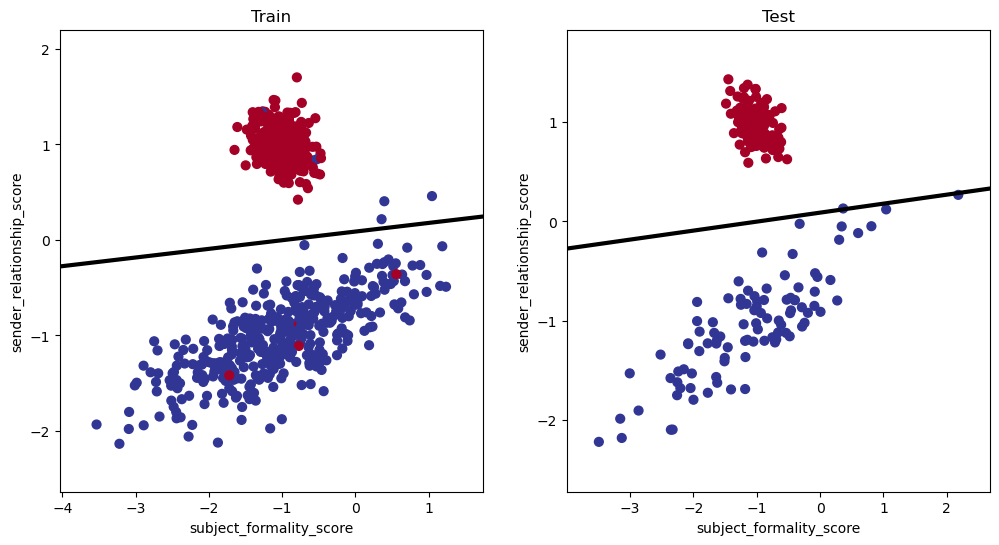

In [31]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()

In [32]:
df = pd.read_csv('08-seismic_activity_svm.csv')

In [33]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [35]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


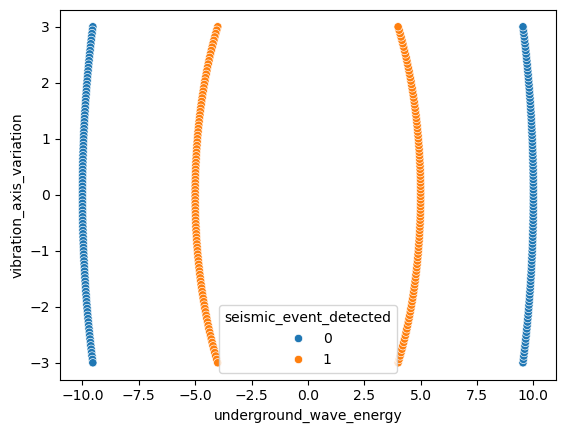

In [36]:
sns.scatterplot(x=df['underground_wave_energy'],y=df['vibration_axis_variation'], hue = df['seismic_event_detected'])
plt.show()

In [37]:
X = df[['underground_wave_energy','vibration_axis_variation']].values
y = df['seismic_event_detected'].values

In [38]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

In [41]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [128]:
import torch.nn as nn

class LinearRegModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# 1. Model ve Optimizer
model = LinearRegModel()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

torch.manual_seed(42)
epochs = 500

for epoch in range(epochs):
    # Training
    model.train() 

    # 1. Forward pass
    y_logits = model(X_train)  # 🛠️ model_0 yerine model!
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Loss & Acc
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_test=y_train, y_pred=y_pred)

    # 3. Optimizer reset
    optimizer.zero_grad()

    # 4. Backprop
    loss.backward()

    # 5. Step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test=y_test, y_pred=test_pred)

    if epoch % 50 == 0:
        print(
            f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%"
        )

Epoch: 0 | Loss: 0.68715, Acc: 57.81% | Test Loss: 0.68227, Test Acc: 58.75%
Epoch: 50 | Loss: 0.61604, Acc: 57.50% | Test Loss: 0.57309, Test Acc: 67.50%
Epoch: 100 | Loss: 0.56989, Acc: 58.13% | Test Loss: 0.53181, Test Acc: 65.00%
Epoch: 150 | Loss: 0.50507, Acc: 70.31% | Test Loss: 0.48124, Test Acc: 71.25%
Epoch: 200 | Loss: 0.41347, Acc: 86.25% | Test Loss: 0.40966, Test Acc: 88.75%
Epoch: 250 | Loss: 0.30355, Acc: 99.69% | Test Loss: 0.29827, Test Acc: 100.00%
Epoch: 300 | Loss: 0.20455, Acc: 100.00% | Test Loss: 0.19371, Test Acc: 100.00%
Epoch: 350 | Loss: 0.12971, Acc: 100.00% | Test Loss: 0.12209, Test Acc: 100.00%
Epoch: 400 | Loss: 0.08212, Acc: 100.00% | Test Loss: 0.07696, Test Acc: 100.00%
Epoch: 450 | Loss: 0.05380, Acc: 100.00% | Test Loss: 0.04980, Test Acc: 100.00%


In [124]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

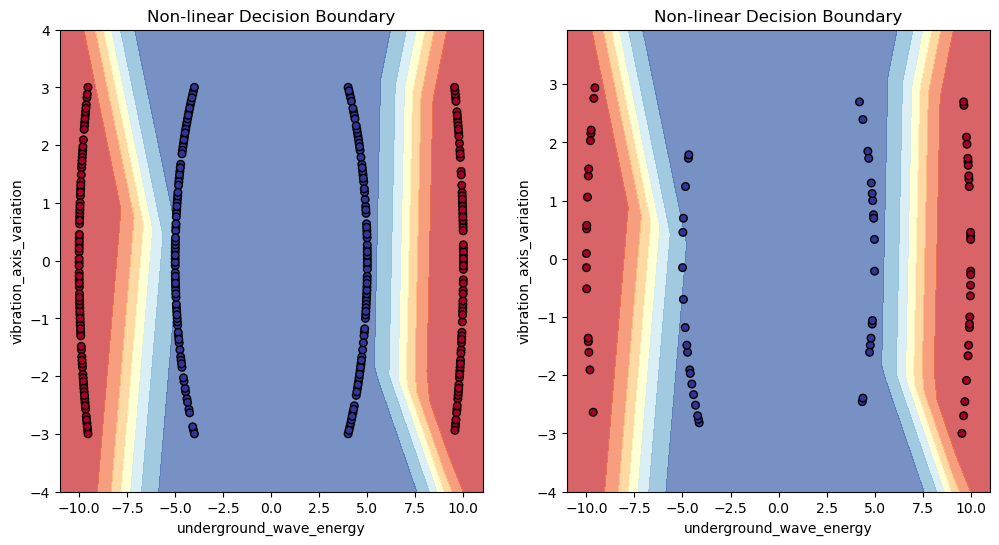

In [126]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()